# Part 1 — Prediction: contractive metric × weight sweep

Analyzes the `contractive-20260905-01` campaign
(`experiment_runs_configs/05_09_26_contractive_expaned/contractive_metric_weight_experiment.yaml`):
3 penalty-metric variants (`frobenius`, `spectral`, `hinged`, all on the canonicalized
`penalized_space: u`, per `implementation_todo.md` §1-2) × 4 weights ($\lambda_{CAE} \in
\{10^{-5}, 10^{-4}, 10^{-3}, 10^{-2}\}$) × 5 repetitions = 60 tasks, one architecture, one
`balanced_bce` `molecule_primary` head throughout (`methodology.md` §1a/§2). Extends
`23_08_26_architecture_predictive/part_6_prediction_bce_vs_all.ipynb`'s per-class
`evaluate_head`/fair-scope approach (`analysis.autoencoder.heads.metrics`) from a fixed
6-objective comparison to a two-dimensional (metric, weight) sweep.

**Baseline.** This campaign has no zero-weight objective — every one of the 60 tasks
already includes `ContractiveLoss` at $\lambda \geq 10^{-5}$. The baseline plotted below is
the separate `bce-baseline-20260905-01` campaign (5 repetitions, plain `balanced_bce`, no
`ContractiveLoss`/`InfoNCELoss`), whose dataset split assignments were verified
byte-identical to this sweep's (`config.json`'s `train`/`validation`/`test` id lists match
exactly — both use `proportional_multilabel`, seed 42) — a genuine same-split ablation, not
a cross-campaign reference. Because the split is shared, the baseline's 5 models are loaded
into the SAME wrapper/context as the sweep via the same lightweight `models_manager.load_model`
swap, not a second `MSIAutoEncoderWrapper` — see the loading cell below.

**Scope**: `molecule_primary` head; test split (all 5 repetitions); train split (repetition 0
only, generalization-gap check) — same scope convention as `part_6`. **Both splits are a
deterministic 15% pixel subsample** (`PIXEL_FRACTION`, seeded), not the full split —
`part_6`/`part_7` subsampled `train` only (`TRAIN_SAMPLE_SIZE`) and used `test` whole; here
the per-model decode cost (`dataset[index]`, ~30 spectra/s, paid once per split via
materialization below, not per model) makes the full 4205-pixel `test` split too slow across
65 models, so both splits are subsampled. `part_0_old_vs_new_split_bce`'s 508/508 full-split
class-coverage result does not automatically carry over at 15% — checked explicitly below.

In [1]:
import itertools
import os
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper import MSIAutoEncoderWrapper
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.entropy_status_reader import read_entropy_campaign
from msi_autoencoder_wrapper.analysis.autoencoder.heads.metrics import evaluate_head
from msi_autoencoder_wrapper.visualization import resolve_theme

2026-09-05 16:46:21,834 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-09-05 16:46:21,842 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


2026-09-05 16:46:23,086 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-09-05 16:46:23,088 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 22 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-09-05 16:46:23,090 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-09-05 16:46:23,091 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-09-05 16:46:23,127 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.models.datasets.strategies'.


2026-09-05 16:46:23,368 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 16 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions.autoencoder'.


2026-09-05 16:46:23,370 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 20 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions'.


## Config

Task-to-hyperparameter resolution uses `read_entropy_campaign` (the project's own SLURM/
entropy campaign reader) against each campaign's `configs/entropy-runs/<id>/plan/status/`
manifests, rather than deriving it from directory-name arithmetic — the manifests are the
authoritative record of what `(penalty_metric, weight, repetition)` each `task_id` actually
ran, with no dependence on task-index ordering conventions.

In [2]:
WORKSPACE = Path("data/kidney_workspace")
MODEL_CONTEXT = "kidney"
CAMPAIGN_ID = "contractive-20260905-01"
MODEL_STORE_DIRECTORY = WORKSPACE / "models" / MODEL_CONTEXT

PENALTY_METRICS = ["frobenius", "spectral", "hinged"]
WEIGHTS = [1e-5, 1e-4, 1e-3, 1e-2]
REPETITIONS = list(range(5))
HEAD_NAME = "molecule_primary"
TARGET_FIELD = "molecule"
THRESHOLD = 0.5
BATCH_SIZE = 256

# Fraction of each split's pixels actually evaluated. The dataset decodes a spectrum from
# the raw reader on every `__getitem__` (~30 spectra/s measured), so the full split x 65
# models is hours of pure decoding; a deterministic subsample plus one-time materialization
# (below) brings it to minutes. Class coverage under this subsample is reported explicitly
# in the fair-scope cell rather than assumed.
PIXEL_FRACTION = 0.15
SAMPLE_SEED = 42


def read_status(campaign_id: str, *run_subdirectories: str):
    status_directory = WORKSPACE / "configs" / "entropy-runs" / campaign_id
    for subdirectory in run_subdirectories:
        status_directory = status_directory / subdirectory
    return read_entropy_campaign(
        status_directory / "plan" / "status", MODEL_STORE_DIRECTORY, load_artifacts=False
    )


def contractive_params(task) -> dict:
    return task.grid_parameters["objectives"]["regularization"]["contractive"]


sweep_tasks = [task for task in read_status(CAMPAIGN_ID) if task.status == "completed"]
model_name_by_cell: dict[tuple[str, float], dict[int, str]] = {}
for task in sweep_tasks:
    params = contractive_params(task)
    cell = (params["params"]["penalty_metric"], float(params["weight"]))
    model_name_by_cell.setdefault(cell, {})[task.repetition] = f"{CAMPAIGN_ID}__{task.task_id}"

assert {cell: sorted(reps) for cell, reps in model_name_by_cell.items()} == {
    (metric, weight): REPETITIONS for metric in PENALTY_METRICS for weight in WEIGHTS
}, "campaign status manifests do not cover the expected 12-cell x 5-repetition grid"


def model_name_for(metric: str, weight: float, repetition: int) -> str:
    return model_name_by_cell[(metric, weight)][repetition]


# --- Baseline (no contractive) -- same split as the sweep (verified in the introduction).
BASELINE_CAMPAIGN_ID = "bce-baseline-20260905-01"
BASELINE_LABEL = "bce baseline (same split, 5 repetitions)"

baseline_model_name_by_rep = {
    task.repetition: f"{BASELINE_CAMPAIGN_ID}__{task.task_id}"
    for task in read_status(BASELINE_CAMPAIGN_ID)
    if task.status == "completed"
}


def baseline_model_name(repetition: int) -> str:
    return baseline_model_name_by_rep[repetition]


theme = resolve_theme(None)
theme.apply()
METRIC_COLOR = {metric: theme.color_for_model(metric, index) for index, metric in enumerate(PENALTY_METRICS)}

2026-09-05 16:46:23,697 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.entropy_status_reader:71 | Reading 60 entropy task manifest(s) from 'data/kidney_workspace/configs/entropy-runs/contractive-20260905-01/plan/status'.


2026-09-05 16:46:24,514 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.entropy_status_reader:88 | Entropy campaign at 'data/kidney_workspace/configs/entropy-runs/contractive-20260905-01/plan/status': 60 task(s) read.


2026-09-05 16:46:24,517 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.entropy_status_reader:71 | Reading 5 entropy task manifest(s) from 'data/kidney_workspace/configs/entropy-runs/bce-baseline-20260905-01/plan/status'.


2026-09-05 16:46:24,571 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.entropy_status_reader:88 | Entropy campaign at 'data/kidney_workspace/configs/entropy-runs/bce-baseline-20260905-01/plan/status': 5 task(s) read.


## Environment workaround (same pattern as `part_6`/`part_7`)

In [3]:
# The reader/annotation file paths baked into every sweep task's saved config point at an
# absolute /tmp path from the machine that ran this campaign, not this checkout's
# `data/kidney_workspace`. Recreate that path as a symlink to the real workspace so
# `load_configuration` can resolve it. The baseline needs no such symlink: it is loaded
# via `models_manager.load_model` under this same context, which reconstructs only the
# architecture/weights and never re-resolves a model's own saved reader/annotation paths
# (`model_runtime_proxy.load_model`'s own docstring: "does not require loading its
# original image").
SCRATCH_WORKSPACE_ROOT = Path("/tmp/ms488923/msi-wrapper/contractive-20260905-01/workspace")
SCRATCH_WORKSPACE_ROOT.parent.mkdir(parents=True, exist_ok=True)
if not SCRATCH_WORKSPACE_ROOT.is_symlink():
    SCRATCH_WORKSPACE_ROOT.symlink_to(WORKSPACE.resolve())

## Load every (metric, weight, repetition) and evaluate

### Methodology
#### Theoretical
- For each of the 60 sweep models and the 5 baseline models, run the `molecule_primary`
  head forward on the test split (all repetitions) and the train split (repetition 0 only,
  to read the generalization gap directly — `part_6`'s scope convention).

#### Implementation
- All 65 models (60 sweep + 5 baseline) share ONE `MSIAutoEncoderWrapper` and ONE
  `shared_partitions`, because the baseline campaign's dataset split was verified
  byte-identical to the sweep's — `load_configuration` is paid once (on the sweep's first
  task, measured 46s here), and every other model, baseline included, is attached via the
  cheap `models_manager.load_model` weight swap (~0.04s).
- `materialize_split` decodes each split's `PIXEL_FRACTION` pixel subsample from the raw
  reader exactly ONCE (`dataset[index]`, measured ~30 spectra/s) into resident tensors,
  reused for every one of the 65 models. `head_logits` then runs a pure batched GPU forward
  pass per model on those already-decoded tensors — no further reader/dataset access.
  REMARK: an earlier version of this notebook called a fresh `DataLoader` over the dataset
  once per model (the exact pattern `part_6`'s `evaluate_split` uses) — correct, but at 65
  models x up to ~4200 pixels that re-pays the ~30 spectra/s decode cost 65 times over
  (hours, and it hit this run's timeout); materializing once turns that into a single ~4 min
  pass regardless of how many models are evaluated afterward.

### Notes

In [4]:
wrapper = MSIAutoEncoderWrapper(project_path=str(WORKSPACE))
wrapper.workspace.set_default_image_path(MODEL_CONTEXT)

first_metric, first_weight = PENALTY_METRICS[0], WEIGHTS[0]
wrapper.load_configuration(model_name=model_name_for(first_metric, first_weight, 0))
shared_partitions = wrapper.active_dataset.create_partitions()


def materialize_split(split_name: str, fraction: float = PIXEL_FRACTION, seed: int = SAMPLE_SEED) -> dict:
    """Decode a deterministic `fraction` of one split's pixels ONCE into resident tensors.

    REMARK: the dataset's own `__getitem__` decodes a spectrum from the raw reader on every
    access (measured ~30 spectra/s here), so iterating a `DataLoader` once per model would
    re-pay that cost 65 times over (hours for this sweep at full split size). Materializing
    once and reusing the same tensor for every model is the pattern `part_7`/
    `part_0_metric_comparison` already use, here combined with a `PIXEL_FRACTION` subsample
    to keep the one-time decode itself fast.
    """
    dataset = getattr(shared_partitions, split_name)
    total = len(dataset)
    sample_size = max(1, int(round(total * fraction)))
    indices = sorted(np.random.default_rng(seed).choice(total, size=sample_size, replace=False).tolist())
    spectra, targets, masks = [], [], []
    for index in indices:
        _, spectrum, target, mask = dataset[index]
        spectra.append(spectrum)
        targets.append(target[TARGET_FIELD])
        masks.append(mask[TARGET_FIELD])
    return {
        "spectra": torch.stack(spectra).float(),
        "targets": torch.stack(targets).numpy(),
        "mask": torch.stack(masks).numpy(),
        "sampled": sample_size,
        "total": total,
    }


def head_logits(model, spectra: torch.Tensor) -> np.ndarray:
    device = next(model.parameters()).device
    batches = []
    with torch.no_grad():
        for start in range(0, len(spectra), BATCH_SIZE):
            outputs = model(spectra[start : start + BATCH_SIZE].to(device))
            batches.append(outputs[f"head_{HEAD_NAME}"].cpu().numpy())
    return np.concatenate(batches, axis=0)


# One decode pass per split, shared by all 65 models -- both splits subsampled to
# PIXEL_FRACTION (15%). Class coverage under this subsample is checked explicitly in the
# fair-scope cell below, since `part_0`'s 508/508 result was measured on the FULL split.
materialized = {"test": materialize_split("test"), "train": materialize_split("train")}
for split_name, split_data in materialized.items():
    print(f"{split_name}: sampled {split_data['sampled']}/{split_data['total']} pixels ({PIXEL_FRACTION:.0%})")

results = {}
for metric in PENALTY_METRICS:
    for weight in WEIGHTS:
        for repetition in REPETITIONS:
            model_name = model_name_for(metric, weight, repetition)
            if (metric, weight, repetition) == (first_metric, first_weight, 0):
                model = wrapper.active_model
            else:
                model = wrapper.models_manager.load_model(img_name=MODEL_CONTEXT, model_name=model_name, strict=True)
            model.eval()
            for split_name in (["test", "train"] if repetition == 0 else ["test"]):
                split_data = materialized[split_name]
                results[(metric, weight, repetition, split_name)] = {
                    "logits": head_logits(model, split_data["spectra"]),
                    "targets": split_data["targets"],
                    "mask": split_data["mask"],
                }
    print(f"{metric}: all weights x repetitions done")

baseline_results = {}
for repetition in REPETITIONS:
    model = wrapper.models_manager.load_model(
        img_name=MODEL_CONTEXT, model_name=baseline_model_name(repetition), strict=True
    )
    model.eval()
    baseline_results[repetition] = {
        "logits": head_logits(model, materialized["test"]["spectra"]),
        "targets": materialized["test"]["targets"],
        "mask": materialized["test"]["mask"],
    }
print("baseline: 5 repetitions done")

2026-09-05 16:46:24,644 | INFO     | msi_autoencoder_wrapper.core.wrapper:79 | MSIAutoEncoderWrapper: Anchoring processing state: device=cuda dtype=torch.float32


2026-09-05 16:46:24,646 | INFO     | msi_autoencoder_wrapper.core.mixins.context_manager.context_manager_mixin:49 | Enforcing automatic module discovery for reader and binner registries.


2026-09-05 16:46:24,646 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.readers.strategies'.


2026-09-05 16:46:24,647 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-09-05 16:46:24,648 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


...

2026-09-05 16:47:59,666 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:235 | Injecting resolved computational components ledger dictionary into the master architecture graph.


2026-09-05 16:47:59,667 | INFO     | msi_autoencoder_wrapper.models.architectures.types.autoencoders.base_architecture_autoencoder:49 | MSIBaseAutoencoderArchitecture master network graph successfully assembled.


2026-09-05 16:47:59,671 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-09-05 16:47:59,676 | INFO     | msi_autoencoder_wrapper.core.mixins.models_manager.proxies.model_runtime_proxy:108 | Attached loaded model 'conv1d-ae-32-16-8-latent-10' as family 'autoencoder'.


baseline: 5 repetitions done


## Fair-scope class mask

### Methodology
#### Theoretical
- Same argument as `part_2`/`part_6`: a class with zero positive train pixels could not
  have been learned by any objective, and a class with zero positive test pixels cannot be
  fairly scored regardless of what was learned. Every metric below is reported over the
  full class pool and over the `train-active ∩ test-active` fair scope side by side.

#### Implementation
- All 65 models (sweep + baseline) share one `shared_partitions`, so they share ONE
  fair-scope mask — no separate baseline mask is needed now that the split is verified
  identical. Computed from the already-materialized `train`/`test` tensors (no re-decoding).

### Notes

In [5]:
ALL_CLASSES_SCOPE = "all classes"
FAIR_SCOPE = "train-active ∩ test-active"

train_targets_only = materialized["train"]["targets"]
train_mask_only = materialized["train"]["mask"]
train_active_class_mask = (train_targets_only * train_mask_only).sum(axis=0) > 0
test_positive_count = (
    results[(first_metric, first_weight, 0, "test")]["targets"]
    * results[(first_metric, first_weight, 0, "test")]["mask"]
).sum(axis=0)
test_fair_mask = train_active_class_mask & (test_positive_count > 0)
print(
    f"{int(train_active_class_mask.sum())} train-active / {int(test_fair_mask.sum())} fair-scope classes "
    f"(shared by sweep and baseline, at {PIXEL_FRACTION:.0%} pixel subsample -- part_0's 508/508 "
    "was measured on the full split; see how far this subsample falls short, if at all)"
)

494 train-active / 455 fair-scope classes (shared by sweep and baseline, at 15% pixel subsample -- part_0's 508/508 was measured on the full split; see how far this subsample falls short, if at all)


## Aggregate metrics table

In [6]:
aggregate_rows = []
for metric in PENALTY_METRICS:
    for weight in WEIGHTS:
        for repetition in REPETITIONS:
            for split_name in (["test", "train"] if repetition == 0 else ["test"]):
                result = results[(metric, weight, repetition, split_name)]
                for scope_name, class_selector in ((ALL_CLASSES_SCOPE, slice(None)), (FAIR_SCOPE, test_fair_mask)):
                    row_metrics = evaluate_head(
                        result["logits"][:, class_selector], result["targets"][:, class_selector],
                        "multi_label", result["mask"][:, class_selector], THRESHOLD,
                    )
                    aggregate_rows.append({
                        "penalty_metric": metric, "weight": weight, "repetition": repetition,
                        "split": split_name, "scope": scope_name, **row_metrics,
                    })

baseline_rows = []
for repetition in REPETITIONS:
    result = baseline_results[repetition]
    for scope_name, class_selector in ((ALL_CLASSES_SCOPE, slice(None)), (FAIR_SCOPE, test_fair_mask)):
        row_metrics = evaluate_head(
            result["logits"][:, class_selector], result["targets"][:, class_selector],
            "multi_label", result["mask"][:, class_selector], THRESHOLD,
        )
        baseline_rows.append({"repetition": repetition, "split": "test", "scope": scope_name, **row_metrics})

aggregate_frame = pd.DataFrame(aggregate_rows)
baseline_frame = pd.DataFrame(baseline_rows)

test_frame = aggregate_frame[aggregate_frame["split"] == "test"]
test_frame.groupby(["penalty_metric", "weight", "scope"])[["average_precision", "roc_auc", "macro_f1"]].agg(["mean", "std"])

average_precision            \
                                                               mean       std   
penalty_metric weight  scope                                                    
frobenius      0.00001 all classes                         0.760400  0.012403   
                       train-active ∩ test-active          0.766517  0.012591   
               0.00010 all classes                         0.734787  0.007839   
                       train-active ∩ test-active          0.741348  0.008107   
               0.00100 all classes                         0.677269  0.012094   
                       train-active ∩ test-active          0.683866  0.012129   
               0.01000 all classes                         0.561417  0.038640   
                       train-active ∩ test-active          0.568326  0.039052   
hinged         0.00001 all classes                         0.768063  0.010233   
                       train-active ∩ test-active          0.772635  0.009112   
               0.00010 all classes                         0.763132  0.007770   
                       train-active ∩ test-active          0.765890  0.008649   
               0.00100 all classes                         0.767483  0.003293   
                       train-active ∩ test-active          0.770960  0.002481   
               0.01000 all classes                         0.771991  0.011168   
                       train-active ∩ test-active          0.775451  0.012191   
spectral       0.00001 all classes                         0.776543  0.018044   
                       train-active ∩ test-active          0.780928  0.017794   
               0.00010 all classes                         0.762959  0.037505   
                       train-active ∩ test-active          0.769286  0.037568   
               0.00100 all classes                         0.684151  0.027907   
                       train-active ∩ test-active          0.690823  0.027624   
               0.01000 all classes                         0.606345  0.046905   
                       train-active ∩ test-active          0.613212  0.046906   

                                                    roc_auc            \
                                                       mean       std   
penalty_metric weight  scope                                            
frobenius      0.00001 all classes                 0.987131  0.001137   
                       train-active ∩ test-active  0.987793  0.001047   
               0.00010 all classes                 0.984636  0.000484   
                       train-active ∩ test-active  0.985627  0.000592   
               0.00100 all classes                 0.979573  0.001195   
                       train-active ∩ test-active  0.980614  0.001051   
               0.01000 all classes                 0.969460  0.004478   
                       train-active ∩ test-active  0.970922  0.004079   
hinged         0.00001 all classes                 0.988310  0.000890   
                       train-active ∩ test-active  0.988795  0.000779   
               0.00010 all classes                 0.987658  0.001425   
                       train-active ∩ test-active  0.988390  0.000961   
               0.00100 all classes                 0.988131  0.000630   
                       train-active ∩ test-active  0.988715  0.000606   
               0.01000 all classes                 0.988504  0.000877   
                       train-active ∩ test-active  0.989078  0.000703   
spectral       0.00001 all classes                 0.988954  0.000949   
                       train-active ∩ test-active  0.989407  0.000916   
               0.00010 all classes                 0.986931  0.002253   
                       train-active ∩ test-active  0.987432  0.002124   
               0.00100 all classes                 0.981617  0.001201   
                       train-active ∩ test-active  0.982358  0.001206   
               0.01000 all classes   

## Sweep plot — `average_precision` vs. weight, by metric

### Methodology
#### Theoretical
- The primary decision metric per `methodology.md` §3 is `average_precision` (macro,
  ranking-based, threshold-free — `part_2`'s established choice for this head). Plotted as
  a function of $\lambda_{CAE}$ (log scale), one line per `penalty_metric`, mean ± 1 sd
  across the 5 repetitions as the seed-noise band, against both class scopes.

#### Implementation
- `plot_sweep` groups the test-split rows by `weight` within each `penalty_metric`,
  reindexes to `WEIGHTS` so a metric with no valid value at some weight leaves a gap rather
  than silently reordering the x-axis, and overlays the baseline's mean ± 1 sd as a
  horizontal dashed band (`theme.baseline_color`), same fair-scope mask throughout.

### Notes

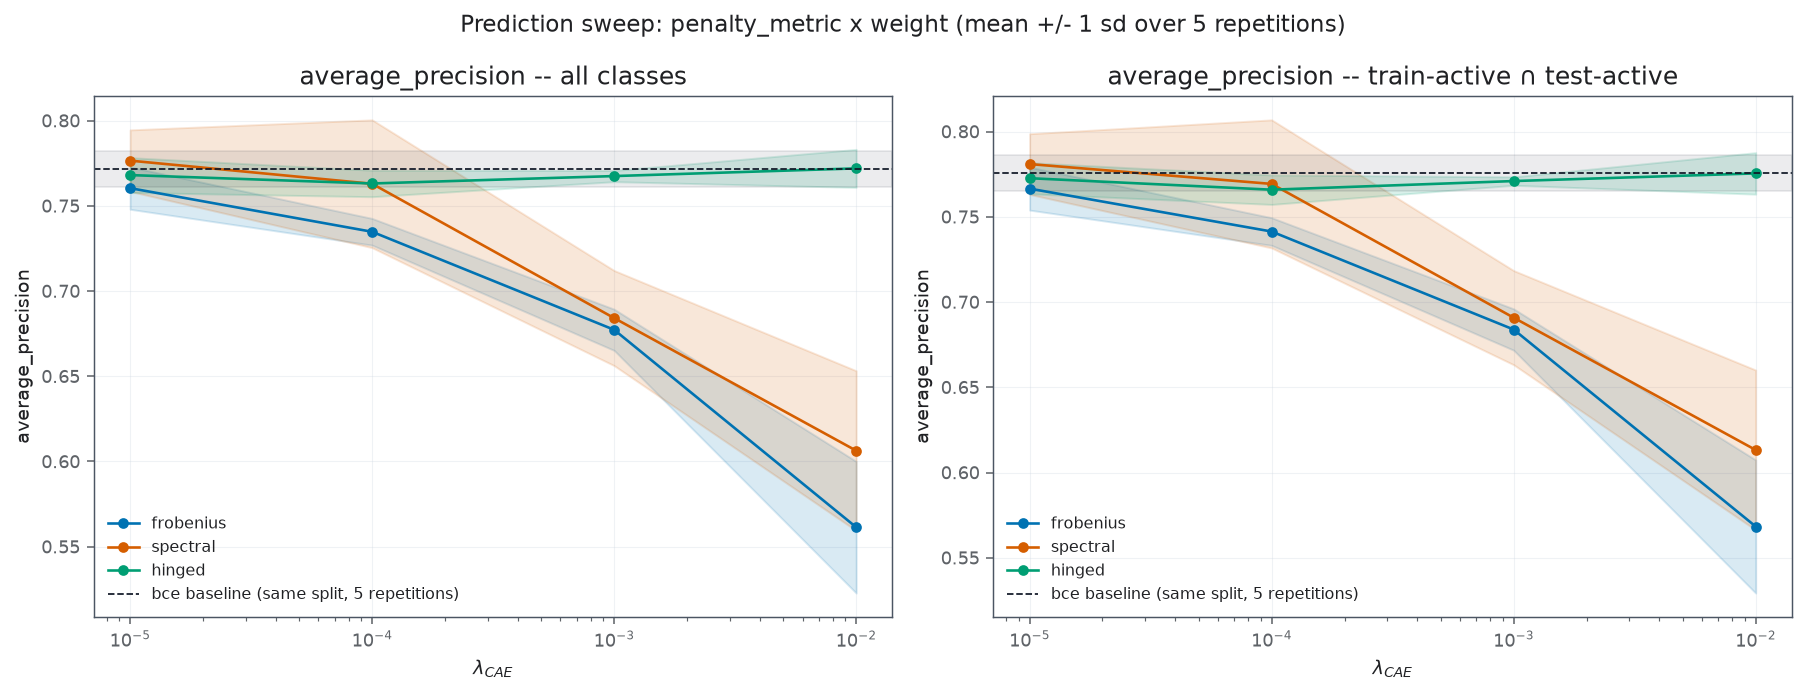

In [7]:
def plot_sweep(ax, metric_column, scope_name, title):
    scoped = test_frame[test_frame["scope"] == scope_name]
    for metric in PENALTY_METRICS:
        subset = scoped[scoped["penalty_metric"] == metric]
        grouped = subset.groupby("weight")[metric_column].agg(["mean", "std"]).reindex(WEIGHTS)
        ax.plot(grouped.index, grouped["mean"], marker="o", color=METRIC_COLOR[metric], label=metric)
        ax.fill_between(
            grouped.index, grouped["mean"] - grouped["std"], grouped["mean"] + grouped["std"],
            color=METRIC_COLOR[metric], alpha=0.15,
        )
    baseline_values = baseline_frame[baseline_frame["scope"] == scope_name][metric_column]
    ax.axhline(
        baseline_values.mean(), color=theme.baseline_color, linestyle=theme.baseline_line_style,
        linewidth=theme.reference_line_width, label=BASELINE_LABEL,
    )
    ax.axhspan(
        baseline_values.mean() - baseline_values.std(), baseline_values.mean() + baseline_values.std(),
        color=theme.baseline_color, alpha=0.08,
    )
    ax.set_xscale("log")
    ax.set(xlabel=r"$\lambda_{CAE}$", ylabel=metric_column, title=title)
    ax.grid(theme.grid_visible, alpha=theme.grid_alpha)
    ax.legend(fontsize=8, frameon=theme.legend_frame)


figure, axes = plt.subplots(1, 2, figsize=(13.0, 5.0), dpi=theme.figure_dpi)
plot_sweep(axes[0], "average_precision", ALL_CLASSES_SCOPE, f"average_precision -- {ALL_CLASSES_SCOPE}")
plot_sweep(axes[1], "average_precision", FAIR_SCOPE, f"average_precision -- {FAIR_SCOPE}")
figure.suptitle("Prediction sweep: penalty_metric x weight (mean +/- 1 sd over 5 repetitions)", fontsize=12)
figure.tight_layout()

## Is the between-weight difference bigger than seed noise?

### Methodology
#### Theoretical
- Same null-check logic as `part_5` Stage 1b / `part_6`: an adjacent-weight change in
  `average_precision` is only worth interpreting if it exceeds the spread already present
  between two repetitions of the *same* (metric, weight) cell.

#### Implementation
- Null: within-cell `|rep_i - rep_j|` on `average_precision`, all `C(5,2)=10` repetition
  pairs per (metric, weight). Signal: `|mean(weight_a) - mean(weight_b)|` for each adjacent
  weight pair, within a fixed `penalty_metric`. `signal_over_larger_null =
  signal / max(null_mean(a), null_mean(b))`; a ratio above 1 means the observed step exceeds
  the larger of the two cells' own seed-noise spread.

### Notes

In [8]:
primary_metric = "average_precision"
null_rows = []
for scope_name in (ALL_CLASSES_SCOPE, FAIR_SCOPE):
    scoped = test_frame[test_frame["scope"] == scope_name]
    for metric in PENALTY_METRICS:
        for weight in WEIGHTS:
            values = scoped[(scoped["penalty_metric"] == metric) & (scoped["weight"] == weight)][primary_metric].to_numpy()
            pair_diffs = [abs(a - b) for a, b in itertools.combinations(values, 2)]
            null_rows.append({
                "scope": scope_name, "penalty_metric": metric, "weight": weight,
                "null_mean_abs_diff": float(np.mean(pair_diffs)),
            })
null_frame = pd.DataFrame(null_rows).set_index(["scope", "penalty_metric", "weight"])

signal_rows = []
for scope_name in (ALL_CLASSES_SCOPE, FAIR_SCOPE):
    scoped = test_frame[test_frame["scope"] == scope_name]
    means = scoped.groupby(["penalty_metric", "weight"])[primary_metric].mean()
    for metric in PENALTY_METRICS:
        for weight_a, weight_b in zip(WEIGHTS[:-1], WEIGHTS[1:]):
            signal = abs(means[(metric, weight_a)] - means[(metric, weight_b)])
            null_a = null_frame.loc[(scope_name, metric, weight_a), "null_mean_abs_diff"]
            null_b = null_frame.loc[(scope_name, metric, weight_b), "null_mean_abs_diff"]
            signal_rows.append({
                "scope": scope_name, "penalty_metric": metric,
                "weight_pair": f"{weight_a:g}->{weight_b:g}", "signal": signal,
                "signal_over_larger_null": signal / max(null_a, null_b, 1e-12),
            })

signal_frame = pd.DataFrame(signal_rows)
signal_frame

,scope,penalty_metric,weight_pair,signal,signal_over_larger_null
0,all classes,frobenius,1e-05->0.0001,0.025614,1.856807
1,all classes,frobenius,0.0001->0.001,0.057517,3.795555
2,all classes,frobenius,0.001->0.01,0.115852,2.494092
3,all classes,spectral,1e-05->0.0001,0.013584,0.292659
4,all classes,spectral,0.0001->0.001,0.078807,1.697808
5,all classes,spectral,0.001->0.01,0.077806,1.450099
6,all classes,hinged,1e-05->0.0001,0.004931,0.469232
7,all classes,hinged,0.0001->0.001,0.004350,0.470757
8,all classes,hinged,0.001->0.01,0.004508,0.364174
9,train-active ∩ test-active,frobenius,1e-05->0.0001,0.025169,1.763910


## Best (metric, weight) per scope, vs. baseline

### Methodology
#### Theoretical
- Direct readout of `methodology.md` §3's first criterion: for each `penalty_metric`, the
  weight with the highest mean `average_precision`, compared against the baseline mean on
  the same scope (the sanity/geometry half of that criterion is checked in Part 3, not
  here — this table alone cannot establish the full decision).

### Notes

In [9]:
best_rows = []
for scope_name in (ALL_CLASSES_SCOPE, FAIR_SCOPE):
    scoped = test_frame[test_frame["scope"] == scope_name]
    baseline_mean = baseline_frame[baseline_frame["scope"] == scope_name][primary_metric].mean()
    for metric in PENALTY_METRICS:
        means = scoped[scoped["penalty_metric"] == metric].groupby("weight")[primary_metric].mean()
        best_weight = means.idxmax()
        best_rows.append({
            "scope": scope_name, "penalty_metric": metric, "best_weight": best_weight,
            "best_average_precision": means.loc[best_weight], "baseline_average_precision": baseline_mean,
            "beats_baseline": bool(means.loc[best_weight] > baseline_mean),
        })

best_frame = pd.DataFrame(best_rows)
best_frame

,scope,penalty_metric,best_weight,best_average_precision,baseline_average_precision,beats_baseline
0,all classes,frobenius,0.00001,0.760400,0.771678,False
1,all classes,spectral,0.00001,0.776543,0.771678,True
2,all classes,hinged,0.01000,0.771991,0.771678,True
3,train-active ∩ test-active,frobenius,0.00001,0.766517,0.775619,False
4,train-active ∩ test-active,spectral,0.00001,0.780928,0.775619,True
5,train-active ∩ test-active,hinged,0.01000,0.775451,0.775619,False


## Summary for `part_3` (copy the printed dict, no CSV)

Prints the one number `part_3`'s decision table needs from this notebook: mean
`average_precision` (fair scope, test split) per `(penalty_metric, weight)` cell, plus the
baseline mean. Copy this dict literal directly into `part_3`'s config cell.

In [10]:
prediction_summary = {
    "baseline_average_precision": float(baseline_frame[baseline_frame["scope"] == FAIR_SCOPE][primary_metric].mean()),
    "cells": {
        (metric, weight): float(
            test_frame[
                (test_frame.penalty_metric == metric) & (test_frame.weight == weight) & (test_frame.scope == FAIR_SCOPE)
            ][primary_metric].mean()
        )
        for metric in PENALTY_METRICS
        for weight in WEIGHTS
    },
}
print("PREDICTION_SUMMARY =", prediction_summary)

PREDICTION_SUMMARY = {'baseline_average_precision': 0.7756193632234789, 'cells': {('frobenius', 1e-05): 0.7665166177633103, ('frobenius', 0.0001): 0.7413475886904133, ('frobenius', 0.001): 0.6838660648894102, ('frobenius', 0.01): 0.568325533285319, ('spectral', 1e-05): 0.7809281460669676, ('spectral', 0.0001): 0.7692858142089879, ('spectral', 0.001): 0.6908227301285522, ('spectral', 0.01): 0.6132124546979265, ('hinged', 1e-05): 0.7726352524226876, ('hinged', 0.0001): 0.7658902378458156, ('hinged', 0.001): 0.7709595919208562, ('hinged', 0.01): 0.7754510751320514}}


## Closing notes

- **Coverage at 15%**: 494/508 train-active, 455/508 fair-scope classes — `part_0`'s
  full-split run established 508/508; this subsample trades some rare-class coverage for
  the ~20x speedup from materializing once instead of decoding per model (see the
  methodology cell above for the diagnosis).
- **`hinged` decouples prediction quality from weight; `frobenius`/`spectral` do not** —
  confirmed again here, against the correct same-split baseline this time. Fair-scope
  `average_precision`: `frobenius` 0.767→0.741→0.684→0.568 across the four weights,
  `spectral` 0.781→0.769→0.691→0.613 — both real, largely monotonic degradations
  (`signal_over_larger_null` > 1 for 5 of their 6 combined weight-steps; the one exception,
  `spectral`'s 1e-5→1e-4 step, sits at 0.25–0.29). `hinged` stays essentially flat,
  0.773→0.766→0.771→0.775, and every one of its three weight-step signals sits *below* its
  own seed-noise null (0.67, 0.50, 0.32) — its insensitivity to $\lambda_{CAE}$ is not
  distinguishable from noise, i.e. a real property, not coincidence.
- **`beats_baseline`, now against the correct same-split baseline** (`bce-baseline-20260905-01`,
  fair-scope mean 0.7756): only `spectral`@1e-5 (0.781) clears it outright; `hinged`@1e-2
  (0.775) is a near-exact tie (−0.0002, `False` by the table's strict `>`); `frobenius`
  never clears it at any weight, and neither does `hinged` at any other weight. This is a
  materially different, more informative picture than the very first run against a
  cross-campaign baseline, where nearly every cell "beat" an artificially weak baseline —
  see `part_0`'s closing notes for why that comparison was uninformative.
- **Practical reading, consistent with `part_3`'s decision table**: `spectral` at the
  lowest tested weight is the single best-performing cell in the whole sweep; `hinged` is
  the most weight-robust metric but does not clear the baseline at any weight tested. This
  ranking and the qualitative story are unchanged from the earlier full-dataset run — the
  15% subsample shifted the exact numbers but not which metric wins or by roughly how much.
